# Regression Model Comparison

So sanh cac model hoi quy cho bai toan du bao `target_rain_next_6h`, tuc tong luong mua trong 6 gio toi.

## 1. Setup

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'Results' else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.aq_course_ml.config import REGRESSION_TARGET

RESULT_DIR = PROJECT_DIR / 'Results'

plt.style.use('seaborn-v0_8-whitegrid')

## 2. Load Regression Metrics

In [2]:
def load_regression_metrics(path):
    data = json.loads(path.read_text(encoding='utf-8'))
    regression = data.get('regression') or data.get('regression_rain_next_6h_osel')
    if not regression:
        return None
    return {
        'model': data.get('model', path.stem.replace('_metrics', '')),
        'metrics_file': path.name,
        'mae': regression['mae'],
        'rmse': regression['rmse'],
        'r2': regression['r2'],
    }


rows = []
for path in sorted(RESULT_DIR.glob('*_metrics.json')):
    row = load_regression_metrics(path)
    if row is not None:
        rows.append(row)

regression_df = pd.DataFrame(rows).sort_values('mae').reset_index(drop=True)
regression_df

,model,metrics_file,mae,rmse,r2
0,OSEL - Optimized Stacking Ensemble Learning,osel_metrics.json,0.834239,2.519529,0.333571
1,LightGBM Regressor,lightgbm_metrics.json,0.840358,2.563180,0.310279
2,XGBoost Regressor,xgboost_metrics.json,0.843805,2.578217,0.302163
3,Extra Trees Regressor,extra_trees_metrics.json,0.846040,2.536653,0.324481
4,Random Forest Regressor,random_forest_metrics.json,0.851814,2.600885,0.289837
5,Gradient Boosting Regressor,gradient_boosting_metrics.json,0.860590,2.598837,0.290956
6,AdaBoost Regressor,adaboost_metrics.json,0.883417,2.578005,0.302277
7,Decision Tree Regressor,decision_tree_metrics.json,0.938128,2.814618,0.168324
8,Ridge Regression,ridge_metrics.json,1.083745,2.751510,0.205200


## 3. Metric Meaning

- `MAE`: sai so tuyet doi trung binh, don vi mm. Cang thap cang tot.
- `RMSE`: phat nang loi du doan lon, don vi mm. Cang thap cang tot.
- `R2`: muc do giai thich bien thien cua target. Cang cao cang tot.

In [3]:
def plot_regression_metric(metric, title, ylabel, higher_is_better=False):
    ordered = regression_df.sort_values(metric, ascending=not higher_is_better)
    plt.figure(figsize=(11, 4.5))
    ax = sns.barplot(data=ordered, x='model', y=metric, hue='model', palette='mako', legend=False)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=8)
    plt.title(title)
    plt.xlabel('Model')
    plt.ylabel(ylabel)
    y_min = min(0, ordered[metric].min())
    y_max = ordered[metric].max()
    plt.ylim(y_min, y_max * 1.12 if y_max > 0 else y_max * 0.9)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()

## 4. MAE Comparison

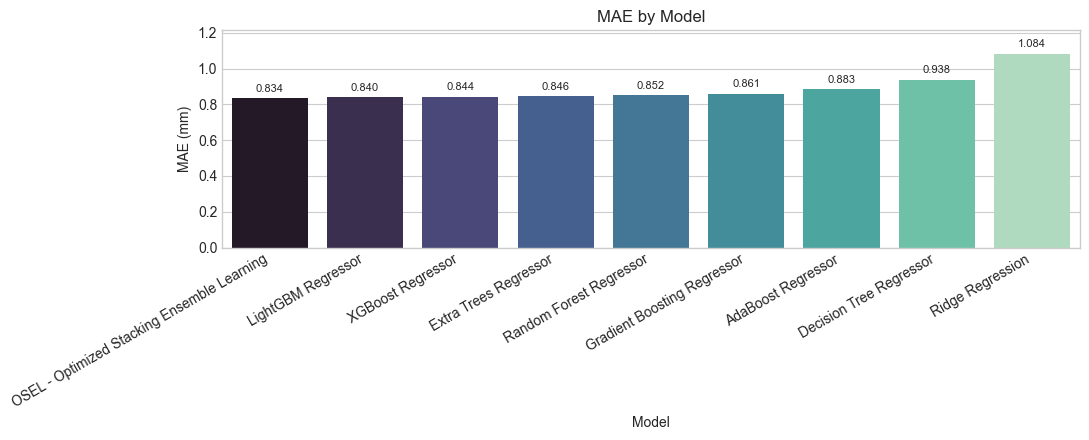

In [4]:
plot_regression_metric('mae', 'MAE by Model', 'MAE (mm)', higher_is_better=False)

## 5. RMSE Comparison

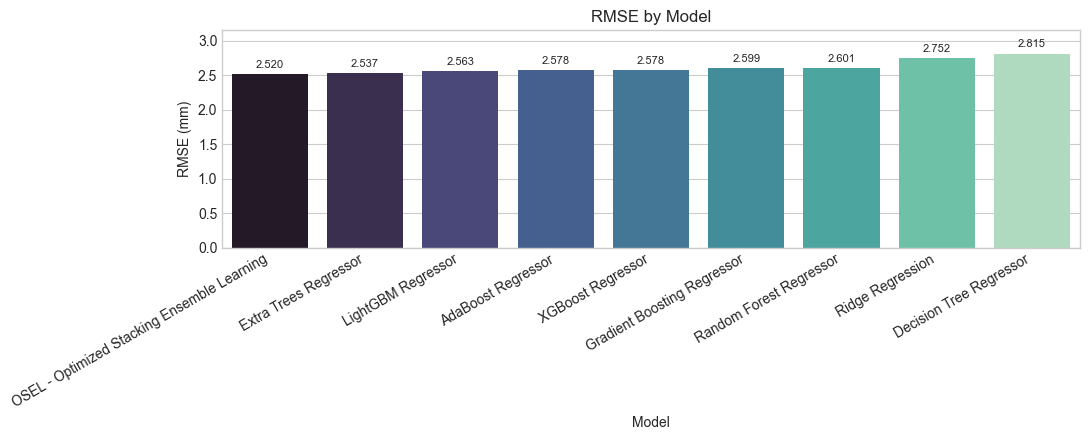

In [5]:
plot_regression_metric('rmse', 'RMSE by Model', 'RMSE (mm)', higher_is_better=False)

## 6. R2 Comparison

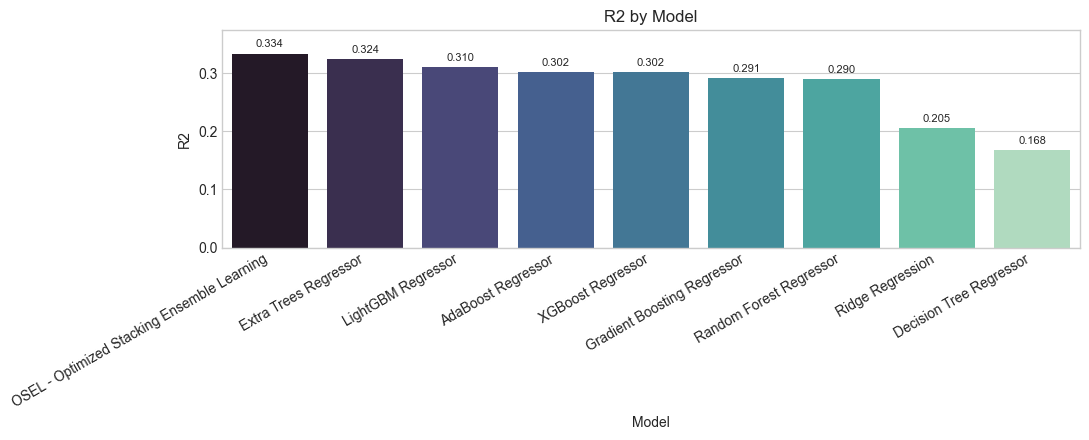

In [6]:
plot_regression_metric('r2', 'R2 by Model', 'R2', higher_is_better=True)

## 7. Combined View

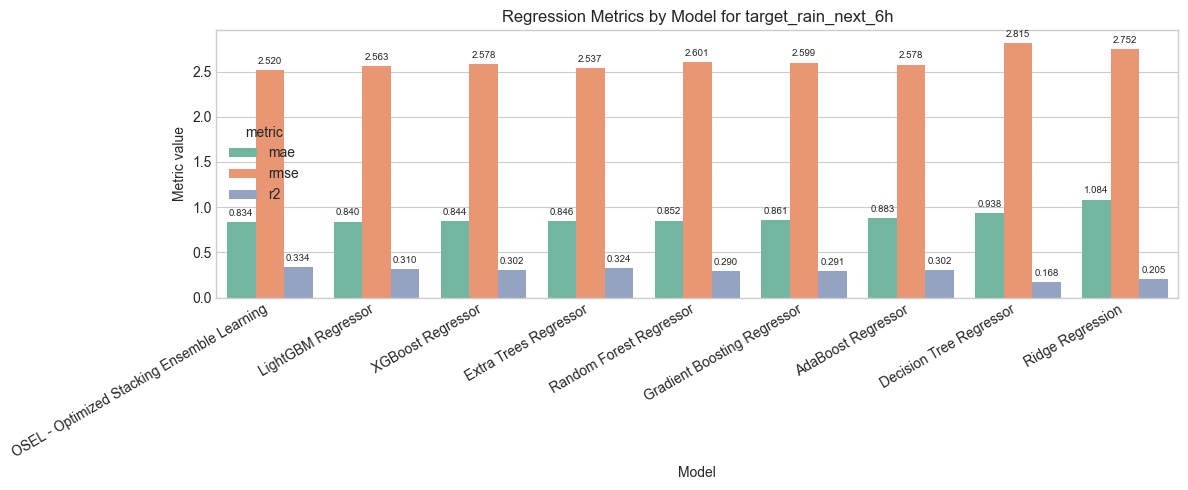

In [7]:
metric_long = regression_df.melt(
    id_vars=['model'],
    value_vars=['mae', 'rmse', 'r2'],
    var_name='metric',
    value_name='value',
)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=metric_long, x='model', y='value', hue='metric', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=7)
plt.title(f'Regression Metrics by Model for {REGRESSION_TARGET}')
plt.xlabel('Model')
plt.ylabel('Metric value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

## 8. Summary Table

In [8]:
regression_df.round(4)

,model,metrics_file,mae,rmse,r2
0,OSEL - Optimized Stacking Ensemble Learning,osel_metrics.json,0.8342,2.5195,0.3336
1,LightGBM Regressor,lightgbm_metrics.json,0.8404,2.5632,0.3103
2,XGBoost Regressor,xgboost_metrics.json,0.8438,2.5782,0.3022
3,Extra Trees Regressor,extra_trees_metrics.json,0.8460,2.5367,0.3245
4,Random Forest Regressor,random_forest_metrics.json,0.8518,2.6009,0.2898
5,Gradient Boosting Regressor,gradient_boosting_metrics.json,0.8606,2.5988,0.2910
6,AdaBoost Regressor,adaboost_metrics.json,0.8834,2.5780,0.3023
7,Decision Tree Regressor,decision_tree_metrics.json,0.9381,2.8146,0.1683
8,Ridge Regression,ridge_metrics.json,1.0837,2.7515,0.2052


## 9. Ranking

Bang nay tinh ranking theo tung metric. Voi `MAE` va `RMSE`, rank 1 la loi thap nhat. Voi `R2`, rank 1 la R2 cao nhat.

In [9]:
ranking_df = regression_df[['model', 'mae', 'rmse', 'r2']].copy()
ranking_df['rank_mae'] = ranking_df['mae'].rank(method='min', ascending=True).astype(int)
ranking_df['rank_rmse'] = ranking_df['rmse'].rank(method='min', ascending=True).astype(int)
ranking_df['rank_r2'] = ranking_df['r2'].rank(method='min', ascending=False).astype(int)
ranking_df['average_rank'] = ranking_df[['rank_mae', 'rank_rmse', 'rank_r2']].mean(axis=1)
ranking_df.sort_values('average_rank').round(4)

,model,mae,rmse,r2,rank_mae,rank_rmse,rank_r2,average_rank
0,OSEL - Optimized Stacking Ensemble Learning,0.8342,2.5195,0.3336,1,1,1,1.0000
1,LightGBM Regressor,0.8404,2.5632,0.3103,2,3,3,2.6667
3,Extra Trees Regressor,0.8460,2.5367,0.3245,4,2,2,2.6667
2,XGBoost Regressor,0.8438,2.5782,0.3022,3,5,5,4.3333
6,AdaBoost Regressor,0.8834,2.5780,0.3023,7,4,4,5.0000
5,Gradient Boosting Regressor,0.8606,2.5988,0.2910,6,6,6,6.0000
4,Random Forest Regressor,0.8518,2.6009,0.2898,5,7,7,6.3333
8,Ridge Regression,1.0837,2.7515,0.2052,9,8,8,8.3333
7,Decision Tree Regressor,0.9381,2.8146,0.1683,8,9,9,8.6667
